# CorrDiff Inference with Custom Checkpoints

Simple workflow to run CorrDiff inference using your trained PhysicsNeMo checkpoints on Earth2Studio.

## Overview
1. Configure paths and variables
2. Load your custom models
3. Run inference
4. Visualize results

## Configuration

In [1]:
# =============================================================================
# CONFIGURATION - Update these paths and variables for your setup
# =============================================================================

# Checkpoint paths
REGRESSION_CHECKPOINT = '/app/host/home/younes.abid/git/physicsnemo/outputs/checkpoints/Fog_index/checkpoints_regression/UNet.0.390000.mdlus'
DIFFUSION_CHECKPOINT = '/app/host/home/younes.abid/git/physicsnemo/outputs/checkpoints/Fog_index/checkpoints_diffusion/EDMPrecondSuperResolution.0.590000.mdlus'

# Data paths
DATA_FILE = '/app/host/mnt/storage/younes.abid/physicsnemo/data/custom_data_2/ERA5_WRF_combined_concatenated_432/2024-04-30_2024-05-30_21.nc'
STATS_FILE = '/app/host/mnt/storage/younes.abid/physicsnemo/data/custom_data_2/stats_432/stat.json'

# Variables
INPUT_VARIABLES = ['t_850', 't_500', 'z_850', 'z_500', 'u_850', 'u_500', 'v_850', 'v_500', 'u10', 'v10', 't2m', 'd2m', 'skt', 'sp', 'tcwv', 'tp']
OUTPUT_VARIABLES = ['Fog_index']

# Domain coordinates (adjust to your training domain)
INPUT_GRID = {
    'lat': (19.25, 28.0, 36),   # (min, max, points)
    'lon': (116.0, 126.0, 40)   # (min, max, points)
}
OUTPUT_GRID = {
    'lat': (19.0, 28.0, 432),   # (min, max, points) 
    'lon': (116.0, 126.0, 432)  # (min, max, points)
}

# Inference settings
INFERENCE_TIME = '2023-01-01T00:00:00'
NUMBER_OF_SAMPLES = 1
NUMBER_OF_STEPS = 8

print('✅ Configuration loaded')

✅ Configuration loaded


## Setup

In [3]:
import os
import sys
import torch
import numpy as np
from collections import OrderedDict

# Add tutorials path
tutorials_path = '/app/host/home/younes.abid/git/earth2studio/notebooks/tutorials'
sys.path.append(tutorials_path)

# Earth2Studio imports
from earth2studio.data import prep_data_array
from earth2studio.io import ZarrBackend
from earth2studio.utils.coords import map_coords, split_coords
from earth2studio.utils.time import to_time_array
from earth2studio.models.batch import batch_coords, batch_func
from earth2studio.models.dx.base import DiagnosticModel
from earth2studio.utils import handshake_coords, handshake_dim

# PhysicsNeMo imports
from physicsnemo.models import Module as PhysicsNemoModule
from physicsnemo.utils.generative import StackedRandomGenerator, deterministic_sampler, stochastic_sampler

# Custom data loader
from custom_data_loader import CustomCorrDiffDataSource

print('✅ Imports successful')

✅ Imports successful


In [2]:
import physicsnemo
print(physicsnemo.__file__)

import physicsnemo.utils.generative as mod
print(dir(mod))

/usr/local/lib/python3.11/dist-packages/physicsnemo/__init__.py
['EasyDict', 'InfiniteSampler', 'StackedRandomGenerator', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'assert_shape', 'call_func_by_name', 'check_ddp_consistency', 'constant', 'construct_class_by_name', 'convert_datetime_to_cftime', 'copy_files_and_create_dirs', 'copy_params_and_buffers', 'ddp_sync', 'deterministic_sampler', 'format_time', 'format_time_brief', 'get_dtype_and_ctype', 'get_module_dir_by_obj_name', 'get_module_from_obj_name', 'get_obj_by_name', 'get_obj_from_module', 'get_top_level_function_name', 'is_top_level_function', 'list_dir_recursively_with_ignore', 'named_params_and_buffers', 'params_and_buffers', 'parse_int_list', 'print_module_summary', 'profiled_function', 'stochastic_sampler', 'suppress_tracer_warnings', 'time_range', 'tuple_product', 'utils']


## Data Source

In [4]:
# Create data source
data_source = CustomCorrDiffDataSource(
    data_paths=[DATA_FILE],
    stats_path=STATS_FILE,
    input_variables=INPUT_VARIABLES,
    output_variables=OUTPUT_VARIABLES,
    cache_data=True
)

print('✅ Data source created')

🔍 Analyzing data files...
  File 1: 2024-04-30_2024-05-30_21.nc - 504 samples
✅ Total samples across all files: 504
📐 Input grid shape: (432, 432)
📐 Lat range: [19.25, 28.00]
📐 Lon range: [116.00, 125.98]
✅ Loaded normalization stats for 16 input variables
💾 Preloading data into memory...
  Loading file 1/1: 2024-04-30_2024-05-30_21.nc
    ✅ Loaded in 6.23s
✅ Data preloading complete!
✅ Data source created


## Model Definition

In [5]:
class FogIndexCorrDiff(torch.nn.Module, DiagnosticModel):
    """Custom CorrDiff model for Fog_index predictions"""
    
    def __init__(self, regression_model, residual_model=None):
        super().__init__()
        self.regression_model = regression_model
        self.residual_model = residual_model
        
        # Grid coordinates
        self.input_lat = np.linspace(*INPUT_GRID['lat'])
        self.input_lon = np.linspace(*INPUT_GRID['lon'])
        self.output_lat = np.linspace(*OUTPUT_GRID['lat'])
        self.output_lon = np.linspace(*OUTPUT_GRID['lon'])
        
        # Normalization (extract from data source)
        self.register_buffer('in_center', torch.from_numpy(data_source.input_mean))
        self.register_buffer('in_scale', torch.from_numpy(data_source.input_std))
        self.register_buffer('out_center', torch.from_numpy(data_source.output_mean) if hasattr(data_source, 'output_mean') else torch.zeros(len(OUTPUT_VARIABLES), 1, 1))
        self.register_buffer('out_scale', torch.from_numpy(data_source.output_std) if hasattr(data_source, 'output_std') else torch.ones(len(OUTPUT_VARIABLES), 1, 1))
        
        self.number_of_samples = NUMBER_OF_SAMPLES
    
    def input_coords(self):
        return OrderedDict({
            'batch': np.empty(0),
            'variable': np.array(INPUT_VARIABLES),
            'lat': self.input_lat,
            'lon': self.input_lon,
        })
    
    @batch_coords()
    def output_coords(self, input_coords):
        output_coords = OrderedDict({
            'batch': np.empty(0),
            'sample': np.arange(self.number_of_samples),
            'variable': np.array(OUTPUT_VARIABLES),
            'lat': self.output_lat,
            'lon': self.output_lon,
        })
        
        # Validate input
        target = self.input_coords()
        handshake_dim(input_coords, 'lon', 3)
        handshake_dim(input_coords, 'lat', 2)
        handshake_dim(input_coords, 'variable', 1)
        handshake_coords(input_coords, target, 'lon')
        handshake_coords(input_coords, target, 'lat')
        handshake_coords(input_coords, target, 'variable')
        
        output_coords['batch'] = input_coords['batch']
        return output_coords
    
    def _interpolate(self, x):
        """Interpolate to output resolution"""
        if x.shape[-2:] == (len(self.output_lat), len(self.output_lon)):
            return x
        
        # Add batch dim if needed
        if len(x.shape) == 3:
            x = x.unsqueeze(0)
            added_batch = True
        else:
            added_batch = False
        
        # Interpolate
        import torch.nn.functional as F
        target_size = (len(self.output_lat), len(self.output_lon))
        x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=True)
        
        # Remove batch dim if added
        if added_batch:
            x = x.squeeze(0)
        
        return x
    
    @torch.inference_mode()
    def _forward(self, x):
        """Forward pass"""
        # Interpolate and normalize
        x = self._interpolate(x)
        x = (x - self.in_center) / self.in_scale
        
        # Add sample dimension
        x = x.unsqueeze(0).repeat(self.number_of_samples, 1, 1, 1)
        
        # Create output tensors
        img_h, img_w = len(self.output_lat), len(self.output_lon)
        latents = torch.zeros(self.number_of_samples, len(OUTPUT_VARIABLES), img_h, img_w, device=x.device)
        
        if self.residual_model is not None:
            # Full diffusion mode
            rnd = StackedRandomGenerator(x.device, torch.arange(self.number_of_samples))
            noise = rnd.randn_like(latents)
            
            # Regression + diffusion
            mean = self.regression_model(latents, x)
            # Then pass BOTH x and mean to the diffusion model
            # The diffusion model expects: [x_channels + mean_channels]
            x_with_mean = torch.cat([x, mean], dim=1)  # Concatenate along channel dimension

            #residual = deterministic_sampler(self.residual_model, noise, x_with_mean, randn_like=rnd.randn_like, num_steps=NUMBER_OF_STEPS)
            residual = stochastic_sampler(self.residual_model, noise, x_with_mean, randn_like=rnd.randn_like, num_steps=NUMBER_OF_STEPS)
            
            x = mean + residual
        else:
            # Regression only
            x = self.regression_model(latents, x)
        
        # Denormalize
        x = self.out_scale * x + self.out_center
        return x
    
    @batch_func()
    def __call__(self, x, coords):
        output_coords = self.output_coords(coords)
        out = torch.zeros([len(v) for v in output_coords.values()], device=x.device, dtype=torch.float32)
        
        for i in range(out.shape[0]):
            out[i] = self._forward(x[i])
        
        return out, output_coords

print('✅ Model class defined')

✅ Model class defined


## Load Models

In [6]:
# Load regression model
print(f'Loading regression model: {REGRESSION_CHECKPOINT}')
regression_model = PhysicsNemoModule.from_checkpoint(REGRESSION_CHECKPOINT).eval()

# Load diffusion model (if exists)
diffusion_model = None
if os.path.exists(DIFFUSION_CHECKPOINT):
    print(f'Loading diffusion model: {DIFFUSION_CHECKPOINT}')
    diffusion_model = PhysicsNemoModule.from_checkpoint(DIFFUSION_CHECKPOINT).eval()
else:
    print('No diffusion model found, using regression-only mode')

# Create CorrDiff model
corrdiff = FogIndexCorrDiff(regression_model, diffusion_model)

print('✅ Models loaded successfully')

Loading regression model: /app/host/home/younes.abid/git/physicsnemo/outputs/checkpoints/Fog_index/checkpoints_regression/UNet.0.390000.mdlus


/usr/local/lib/python3.11/dist-packages/physicsnemo/models/module.py:460: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(


Loading diffusion model: /app/host/home/younes.abid/git/physicsnemo/outputs/checkpoints/Fog_index/checkpoints_diffusion/EDMPrecondSuperResolution.0.590000.mdlus
✅ Models loaded successfully


## Run Inference

In [7]:
# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
corrdiff = corrdiff.to(device)
io = ZarrBackend()

print(f'🚀 Running inference on {device}')

# Load data
time = to_time_array([INFERENCE_TIME])
x, coords = prep_data_array(data_source(time, INPUT_VARIABLES), device=device)
x, coords = map_coords(x, coords, corrdiff.input_coords())

print(f'📊 Input data shape: {x.shape}')

# Setup output
output_coords = corrdiff.output_coords(corrdiff.input_coords())
total_coords = OrderedDict({
    'time': coords['time'],
    'sample': output_coords['sample'],
    'lat': output_coords['lat'],
    'lon': output_coords['lon'],
})
io.add_array(total_coords, output_coords['variable'])

# Run inference
x, coords = corrdiff(x, coords)
io.write(*split_coords(x, coords))

print('✅ Inference complete!')
print(f'Output variables: {list(io)}')
for var in io:
    print(f'  {var}: {io[var].shape}')

🚀 Running inference on cuda
🔄 Loading data for 1 times and 16 variables
✅ Loaded DataArray with shape: (1, 16, 432, 432)
📊 Input data shape: torch.Size([1, 16, 36, 40])
2026-02-03 06:32:27.039 | WARNING  | earth2studio.io.zarr:add_array:192 - Datetime64 not supported in zarr 3.0, converting to int64 nanoseconds since epoch


/usr/local/lib/python3.11/dist-packages/physicsnemo/models/diffusion/layers.py:701: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=self.amp_mode):


✅ Inference complete!
Output variables: ['Fog_index', 'lon', 'sample', 'time', 'lat']
  Fog_index: (1, 1, 432, 432)
  lon: (432,)
  sample: (1,)
  time: (1,)
  lat: (432,)


## Visualization

✅ Visualization saved to outputs/fog_index_prediction.jpg


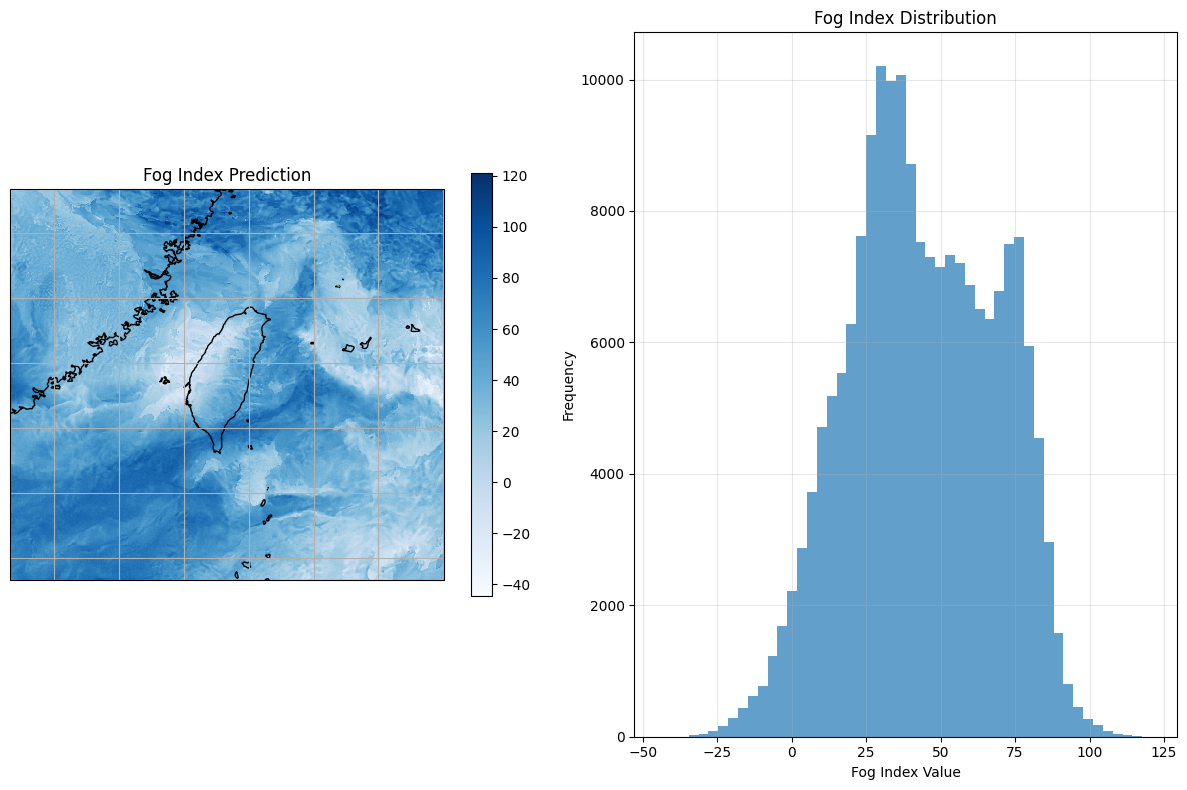

📈 Fog Index Statistics:
   Min: -44.5284
   Max: 121.0377
   Mean: 43.8651
   Std: 24.6741


In [8]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Plot Fog_index results
if 'Fog_index' in io:
    fig = plt.figure(figsize=(12, 8))
    
    # Original Fog_index
    ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
    data = io['Fog_index'][0, 0]  # [time, sample, lat, lon]
    c1 = ax1.pcolormesh(io['lon'], io['lat'], data, transform=ccrs.PlateCarree(), cmap='Blues')
    ax1.coastlines()
    ax1.gridlines()
    ax1.set_title('Fog Index Prediction')
    plt.colorbar(c1, ax=ax1, shrink=0.6)
    
    # Statistics
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.hist(data.flatten(), bins=50, alpha=0.7)
    ax2.set_xlabel('Fog Index Value')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Fog Index Distribution')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('outputs/fog_index_prediction.jpg', dpi=150, bbox_inches='tight')
    print('✅ Visualization saved to outputs/fog_index_prediction.jpg')
    plt.show()
    
    # Print statistics
    print(f'📈 Fog Index Statistics:')
    print(f'   Min: {data.min():.4f}')
    print(f'   Max: {data.max():.4f}')
    print(f'   Mean: {data.mean():.4f}')
    print(f'   Std: {data.std():.4f}')
else:
    print('❌ No Fog_index variable found in output')
    print(f'Available variables: {list(io.keys())}')